In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Vehicle Price/auto_imports1.csv")

In [4]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    object 
 2   make               201 non-null    object 
 3   fuel-type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num-of-doors       201 non-null    object 
 6   body-style         201 non-null    object 
 7   drive-wheels       201 non-null    object 
 8   engine-location    201 non-null    object 
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    object 
 15  num-of-cylinders   201 non-null    object 
 16  engine-size        201 non

In [6]:
df.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg,price
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,10.164279,25.179104,30.686567,13207.129353
std,1.254802,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,4.004965,6.423220,6.815150,7947.066342
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,8.600000,19.000000,25.000000,7775.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000,10295.000000
75%,2.000000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,9.400000,30.000000,34.000000,16500.000000
max,3.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000,45400.000000


In [7]:
df.isnull().sum()

,0
symboling,0
normalized-losses,0
make,0
fuel-type,0
aspiration,0
num-of-doors,0
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0


In [8]:
df=df.replace("?",np.nan)

In [9]:
for col in ["normalized-losses","bore","stroke","horsepower","peak-rpm"]:
  df[col] = pd.to_numeric(df[col])
  df[col]=df[col].fillna(df[col].mean())

In [10]:
df["num-of-doors"]=df["num-of-doors"].fillna(df[col].mean())

df["num-of-doors"]=df["num-of-doors"].replace({"two":2,"four":4})

/tmp/ipykernel_3037/3935006246.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["num-of-doors"]=df["num-of-doors"].replace({"two":2,"four":4})


In [11]:
df['peak-rpm'].dtype

dtype('float64')

In [12]:
df['horsepower'].dtype

dtype('float64')

In [13]:
df['engine-type'].unique()
df['engine-type']=df['engine-type'].replace("l",df['engine-type'].mode()[0])

In [14]:
df['horsepower']=df['horsepower'].fillna(df['horsepower'].mean())
df['peak-rpm']=df['peak-rpm'].fillna(df['peak-rpm'].mean())

In [15]:
for col in ["make","fuel-type","aspiration","body-style","drive-wheels","engine-location","engine-type","fuel-system"]:
  print(col,df[col].unique())

make ['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'mercedes-benz' 'mercury' 'mitsubishi' 'nissan' 'peugot'
 'plymouth' 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen'
 'volvo']
fuel-type ['gas' 'diesel']
aspiration ['std' 'turbo']
body-style ['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']
drive-wheels ['rwd' 'fwd' '4wd']
engine-location ['front' 'rear']
engine-type ['dohc' 'ohcv' 'ohc' 'rotor' 'ohcf']
fuel-system ['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi']


In [16]:
df["num-of-cylinders"]=df["num-of-cylinders"].replace({"two":2,"three":3,"four":4,"five":5,"six":6,"eight":8,"twelve":12})

/tmp/ipykernel_3037/1367498563.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["num-of-cylinders"]=df["num-of-cylinders"].replace({"two":2,"three":3,"four":4,"five":5,"six":6,"eight":8,"twelve":12})


In [17]:
from sklearn.preprocessing import OneHotEncoder

ohe=OneHotEncoder()

encoded=ohe.fit_transform(df[["make","fuel-type","aspiration","body-style","drive-wheels","engine-location","engine-type","fuel-system"]])

df_encoded=pd.get_dummies(df,columns=["make","fuel-type","aspiration","body-style","drive-wheels","engine-location","engine-type","fuel-system"],dtype=int)

In [18]:
df_encoded

,symboling,normalized-losses,num-of-doors,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,...,engine-type_ohcv,engine-type_rotor,fuel-system_1bbl,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
0,3,122.0,2.0,88.6,168.8,64.1,48.8,2548,4,130,...,0,0,0,0,0,0,0,1,0,0
1,3,122.0,2.0,88.6,168.8,64.1,48.8,2548,4,130,...,0,0,0,0,0,0,0,1,0,0
2,1,122.0,2.0,94.5,171.2,65.5,52.4,2823,6,152,...,1,0,0,0,0,0,0,1,0,0
3,2,164.0,4.0,99.8,176.6,66.2,54.3,2337,4,109,...,0,0,0,0,0,0,0,1,0,0
4,2,164.0,4.0,99.4,176.6,66.4,54.3,2824,5,136,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-1,95.0,4.0,109.1,188.8,68.9,55.5,2952,4,141,...,0,0,0,0,0,0,0,1,0,0
197,-1,95.0,4.0,109.1,188.8,68.8,55.5,3049,4,141,...,0,0,0,0,0,0,0,1,0,0
198,-1,95.0,4.0,109.1,188.8,68.9,55.5,3012,6,173,...,1,0,0,0,0,0,0,1,0,0
199,-1,95.0,4.0,109.1,188.8,68.9,55.5,3217,6,145,...,0,0,0,0,0,1,0,0,0,0


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

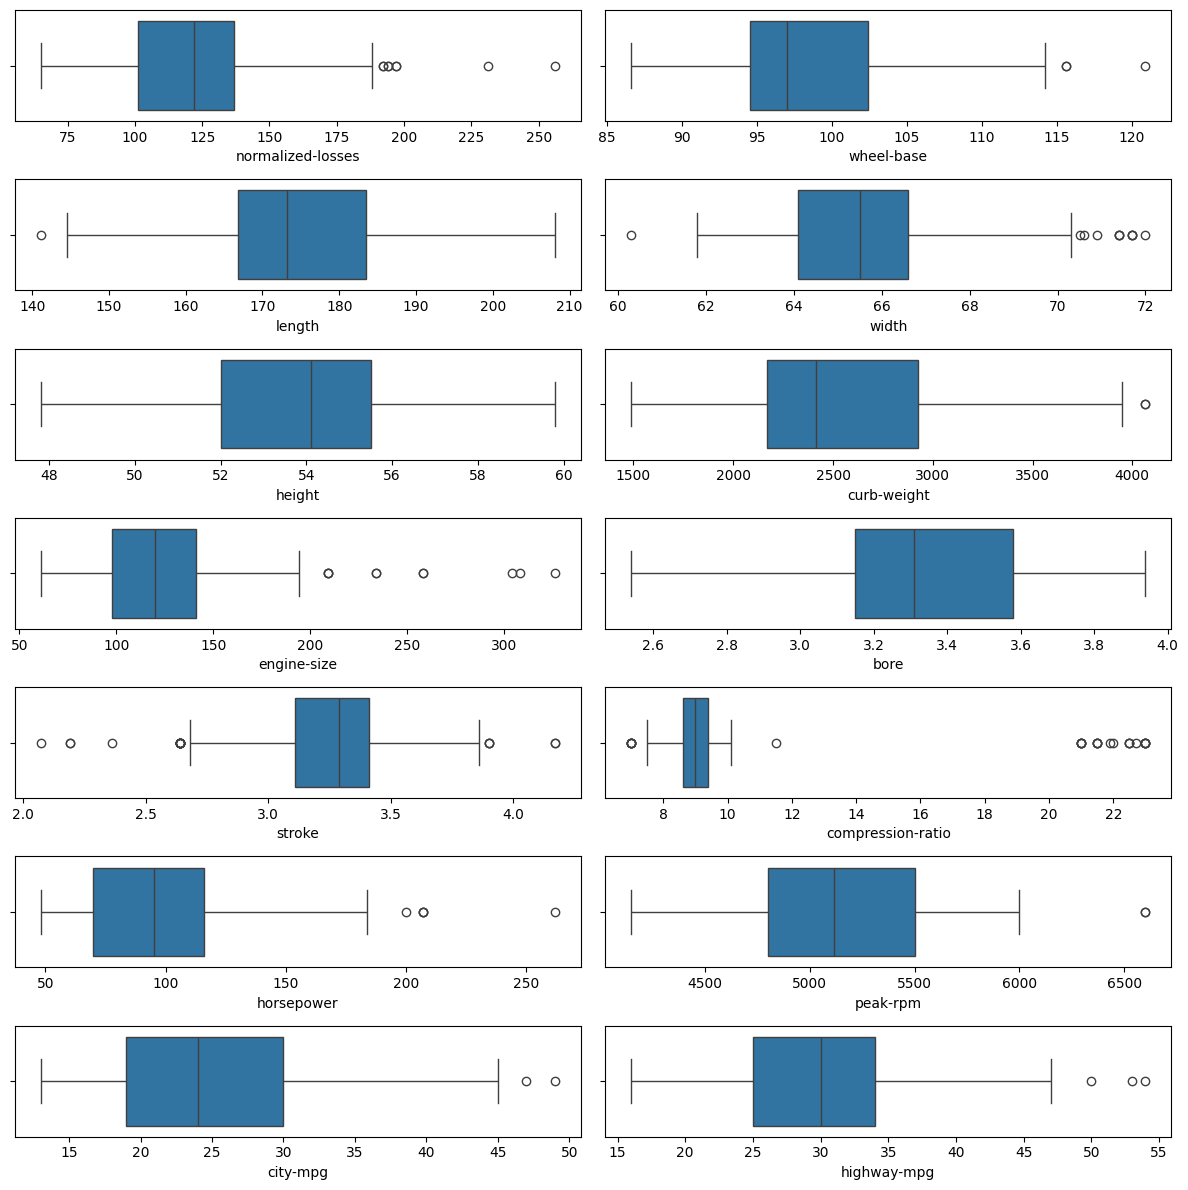

In [20]:
cols = ["normalized-losses","wheel-base","length","width","height","curb-weight","engine-size","bore","stroke","compression-ratio","horsepower","peak-rpm","city-mpg","highway-mpg"]
plt.figure(figsize=(12,12),facecolor="white")

for plot, col in enumerate(cols, start=1):
    plt.subplot(7, 2, plot)
    sns.boxplot(x=df[col])
    plt.xlabel(col)
plt.tight_layout()
plt.show()


In [21]:
num_cols = ["normalized-losses","wheel-base","length","width","height","curb-weight",
            "engine-size","bore","stroke","compression-ratio","horsepower","peak-rpm",
            "city-mpg","highway-mpg"]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

rows = []
for col in num_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    rows.append([col, round(low,2), round(high,2), n_out, round(100*n_out/len(df),1)])

outlier_summary = pd.DataFrame(rows, columns=["column","lower_fence","upper_fence","n_outliers","pct"])
print(outlier_summary.sort_values("n_outliers", ascending=False))

               column  lower_fence  upper_fence  n_outliers   pct
9   compression-ratio         7.40        10.60          27  13.4
8              stroke         2.66         3.86          20  10.0
3               width        60.35        70.35          11   5.5
6         engine-size        33.50       205.50          10   5.0
0   normalized-losses        47.00       191.00           8   4.0
10         horsepower         1.00       185.00           5   2.5
13        highway-mpg        11.50        47.50           3   1.5
1          wheel-base        82.65       114.25           3   1.5
5         curb-weight      1033.50      4061.50           2   1.0
11           peak-rpm      3750.00      6550.00           2   1.0
12           city-mpg         2.50        46.50           2   1.0
2              length       141.75       208.55           1   0.5
4              height        46.75        60.75           0   0.0
7                bore         2.50         4.23           0   0.0


In [22]:
## Normalized-lossed outliers

q1 = df['normalized-losses'].quantile(0.25)
q3 = df['normalized-losses'].quantile(0.75)
iqr_norma=q3-q1
low_norma=q1-1.5*iqr_norma
high_norma=q3+1.5*iqr_norma

median_norma=df['normalized-losses'].mean()

df.loc[df['normalized-losses'] < low_norma, 'normalized-losses'] = median_norma
df.loc[df['normalized-losses'] > high_norma, 'normalized-losses'] = median_norma

In [23]:
## highway-mpg outliers

q1 = df['highway-mpg'].quantile(0.25)
q3 = df['highway-mpg'].quantile(0.75)
iqr_highway=q3-q1
low_highway=q1-1.5*iqr_highway
high_highway=q3+1.5*iqr_highway

mean_highway = df['highway-mpg'].mean()

df.loc[df['highway-mpg'] < low_highway, 'highway-mpg'] = mean_highway
df.loc[df['highway-mpg'] > high_highway, 'highway-mpg'] = mean_highway

/tmp/ipykernel_3037/641393703.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '30.686567164179106' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['highway-mpg'] < low_highway, 'highway-mpg'] = mean_highway


In [24]:
## city-mpg outliers

q1 = df['city-mpg'].quantile(0.25)
q3 = df['city-mpg'].quantile(0.75)
iqr_city=q3-q1
low_city=q1-1.5*iqr_city
high_city=q3+1.5*iqr_city

mean_city = df['city-mpg'].mean()

df.loc[df['city-mpg'] < low_city, 'city-mpg'] = mean_city
df.loc[df['city-mpg'] > high_city, 'city-mpg'] = mean_city

/tmp/ipykernel_3037/1932118251.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '25.17910447761194' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['city-mpg'] < low_city, 'city-mpg'] = mean_city


In [25]:
## stroke outliers

q1 = df['stroke'].quantile(0.25)
q3 = df['stroke'].quantile(0.75)
iqr_stroke=q3-q1
low_stroke=q1-1.5*iqr_stroke
high_stroke=q3+1.5*iqr_stroke

mean_stroke = df['stroke'].mean()

df.loc[df['stroke'] < low_stroke, 'stroke'] = mean_stroke
df.loc[df['stroke'] > high_stroke, 'stroke'] = mean_stroke

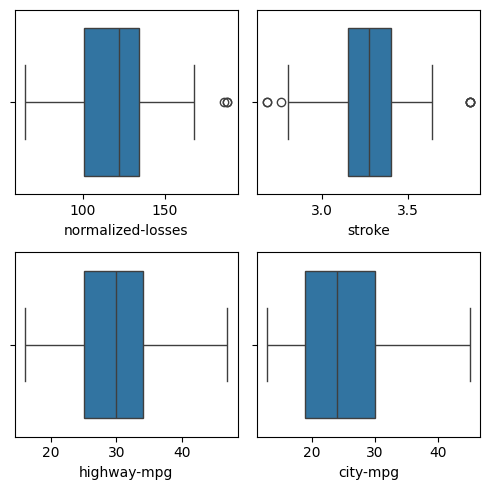

In [26]:
cols = ["normalized-losses","stroke","highway-mpg","city-mpg"]
plt.figure(figsize=(5,5),facecolor="white")

for plot, col in enumerate(cols, start=1):
    plt.subplot(2, 2, plot)
    sns.boxplot(x=df[col])
    plt.xlabel(col)
plt.tight_layout()
plt.show()

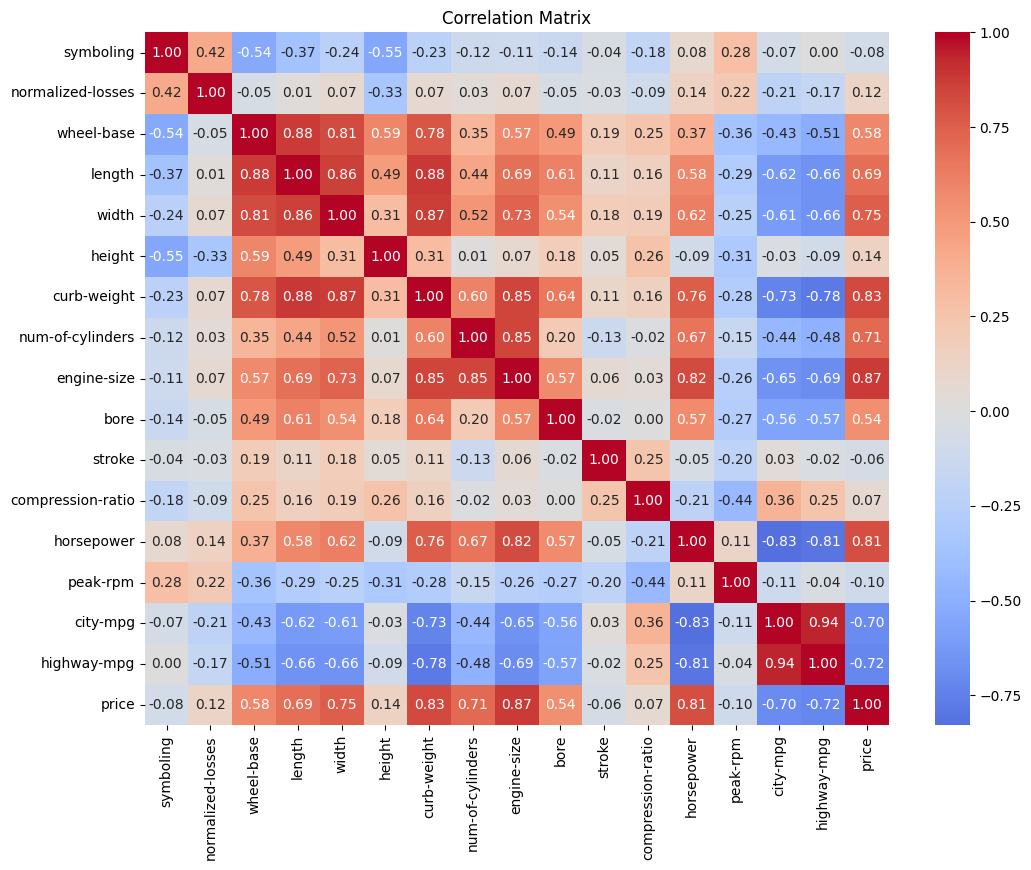

In [27]:
num_cols = ["symboling","normalized-losses","wheel-base","length","width","height","curb-weight","num-of-cylinders",
            "engine-size","bore","stroke","compression-ratio","horsepower","peak-rpm",
            "city-mpg","highway-mpg","price"]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 9))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet, ElasticNetCV

x=df_encoded.drop(["price","city-mpg"],axis=1)
y=df_encoded["price"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [31]:
elastic_cv=ElasticNetCV(alphas=[0.01,0.1,1,5,10,50,100],l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], cv=5, max_iter=10000)
model=elastic_cv.fit(x_train_scaled,y_train)

y_pred=model.predict(x_test_scaled)

from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error,root_mean_squared_error

mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print(mse)
print(mae)
print(rmse)
print(r2)

11818594.65033517
2043.4994158373188
3437.818298039495
0.9034008470141873


In [32]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(ElasticNet(alpha=elastic_cv.alpha_,l1_ratio=elastic_cv.l1_ratio_,max_iter=10000), x_train_scaled, y_train, cv=5, scoring='r2')
print(scores, scores.mean(), scores.min(),scores.max(),scores.std())

[0.87849089 0.95814098 0.85614386 0.83793646 0.83867127] 0.8738766917178165 0.8379364614073171 0.9581409762647558 0.04464825972254894


In [33]:
comparison = pd.DataFrame({"actual": y_test, "predicted": y_pred})
comparison["error"] = comparison["actual"] - comparison["predicted"]
comparison.sort_values("error", key=abs, ascending=False).head(10)

,actual,predicted,error
15,41315,25744.721390,15570.278610
16,36880,27766.669574,9113.330426
45,35550,29290.978263,6259.021737
125,37028,32640.257065,4387.742935
164,9639,13744.519103,-4105.519103
55,15645,12210.615640,3434.384360
104,11900,14933.217888,-3033.217888
124,34028,31248.123252,2779.876748
165,9989,12721.832638,-2732.832638
82,6989,9578.280671,-2589.280671


In [34]:
coefficients = pd.DataFrame({
    "feature": x_train.columns,
    "coefficient": model.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print(coefficients.head(20))

                   feature  coefficient
25      make_mercedes-benz  1075.883565
9              engine-size   911.991886
18                make_bmw   775.633502
8         num-of-cylinders   741.697957
5                    width   696.338769
7              curb-weight   668.451523
13              horsepower   579.418595
3               wheel-base   577.197247
31            make_porsche   530.866555
23             make_jaguar   475.125227
35             make_toyota  -460.821836
4                   length   381.282042
29             make_peugot  -368.083581
17               make_audi   347.857505
42  body-style_convertible   345.348901
51    engine-location_rear   335.999275
50   engine-location_front  -335.994856
49        drive-wheels_rwd   326.200500
48        drive-wheels_fwd  -312.135954
28             make_nissan  -297.386883


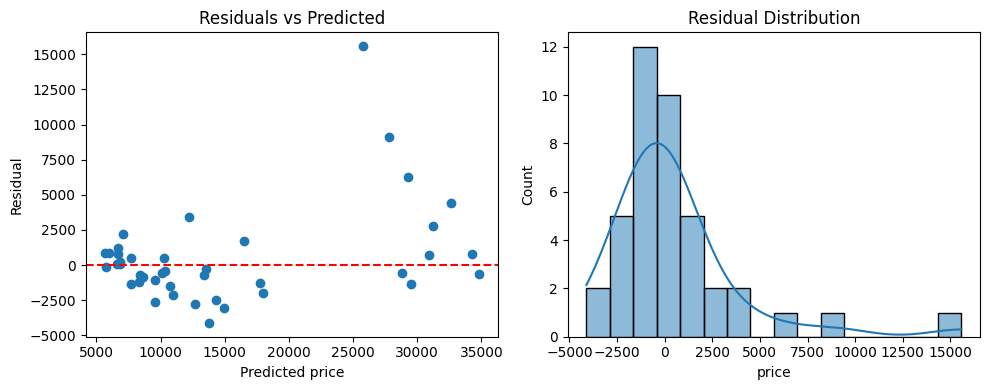

In [35]:
residuals = y_test - y_pred

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted price"); plt.ylabel("Residual")
plt.title("Residuals vs Predicted")

plt.subplot(1,2,2)
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()

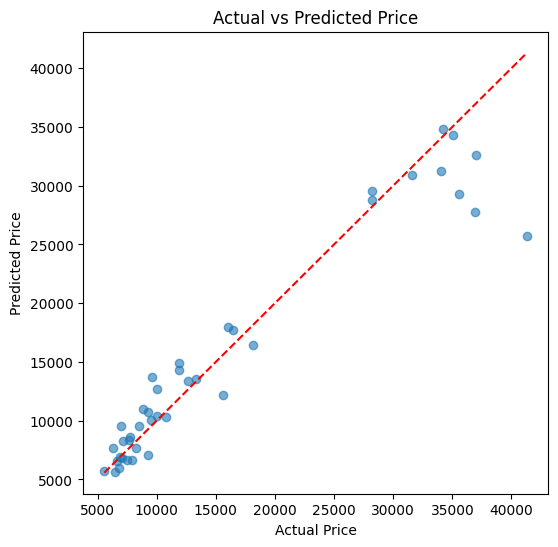

In [36]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price"); plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

In [38]:
import pickle

bundle = {
    'model': model,
    'feature_columns': x_train.columns.tolist(),
    'scaler': scaler,
    'best_alpha': elastic_cv.alpha_,
    'best_l1_ratio': elastic_cv.l1_ratio_,
    'num_doors_map': {"two": 2, "four": 4},
    'num_cylinders_map': {"two":2,"three":3,"four":4,"five":5,"six":6,"eight":8,"twelve":12},
    'engine_type_mode_fill': df['engine-type'].mode()[0],
    'categorical_cols': ["make","fuel-type","aspiration","body-style","drive-wheels","engine-location","engine-type","fuel-system"],
    'dropped_cols': ["city-mpg"],
}

save_path = '/content/drive/MyDrive/Colab Notebooks/Vehicle Price/Final/model.pkl'

with open(save_path, 'wb') as f:
    pickle.dump(bundle, f)

print("Saved model.pkl with", len(bundle['feature_columns']), "feature columns")
print(bundle.keys())
print(bundle['best_alpha'], bundle['best_l1_ratio'])

Saved model.pkl with 65 feature columns
dict_keys(['model', 'feature_columns', 'scaler', 'best_alpha', 'best_l1_ratio', 'num_doors_map', 'num_cylinders_map', 'engine_type_mode_fill', 'categorical_cols', 'dropped_cols'])
1.0 0.7
